In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

/global/homes/s/sferrett/.conda/envs/monsoon-discovery/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NN_SEEDS           = MODELS['nn']['seeds']

COLORS = {}
LABELS = {}
for name,cfg in MODELS['sr']['optimizedeqs'].items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

MINSAMP = 30
NBINS   = 40

In [3]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields * weights[None,:,:] * dsig[None,None,:]
    if mask is not None:
        w = w * mask[:,None,:]
    return w.sum(axis=2)

def to_phys(srout):
    return np.expm1(tpstd * np.maximum(0.0,np.asarray(srout,dtype=float)))

def bin1d(x,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    finite = np.isfinite(x) & np.isfinite(z)
    x,z    = x[finite],z[finite]
    edges  = np.unique(np.percentile(x,np.linspace(plo,phi,nbins+1)))
    n      = len(edges)-1
    xi     = np.clip(np.digitize(x,edges)-1,0,n-1)
    means  = np.full(n,np.nan); counts = np.zeros(n,int)
    for i in range(n):
        sel = xi==i; counts[i] = sel.sum()
        if counts[i]>=minsamp: means[i] = z[sel].mean()
    return edges,0.5*(edges[:-1]+edges[1:]),means,counts

def prange(arr,lo=1,hi=99):
    a = arr[np.isfinite(arr)]
    return float(np.percentile(a,lo)),float(np.percentile(a,hi))

In [4]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']; nlat = ds.sizes['lat']; nlon = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    refshape = (ntime,nlat,nlon)
    lats = ds.lat.values; lons = ds.lon.values
    dsig = ds['dsig'].values
    levmin,levmax = CONFIGS['domain']['levrange']
    sigcoords = (ds.coords['sig'].values if 'sig' in ds.coords
                 else np.linspace(levmin/1000,levmax/1000,nsig))
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  for v in SR_GAUSS_FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    def getflat(da):
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values,(ntime,1,1)).ravel()
    lfnorm  = getflat(ds['lf'])  if 'lf'  in ds else None
    shfnorm = getflat(ds['shf']) if 'shf' in ds else None

kwlist = []
for seed in NN_SEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)
            if 'sig' in wds.coords and len(kwlist)==1:
                sigcoords = wds.coords['sig'].values

if kwlist:
    ki          = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0)
    rhk         = ki[:,0]
    thetaek     = ki[:,1]
    thetaestark = ki[:,2]
else:
    rhk         = fieldstack[:,0,:].mean(axis=1)
    thetaek     = fieldstack[:,1,:].mean(axis=1)
    thetaestark = fieldstack[:,2,:].mean(axis=1)

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    trueflat = ds.tp.transpose('time','lat','lon').values.ravel()

regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath,'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

valid = (np.isfinite(trueflat) & np.isfinite(rhk) &
         np.isfinite(thetaek) & np.isfinite(thetaestark))
print(f'Valid samples: {valid.sum():,}')

Valid samples: 1,437,408


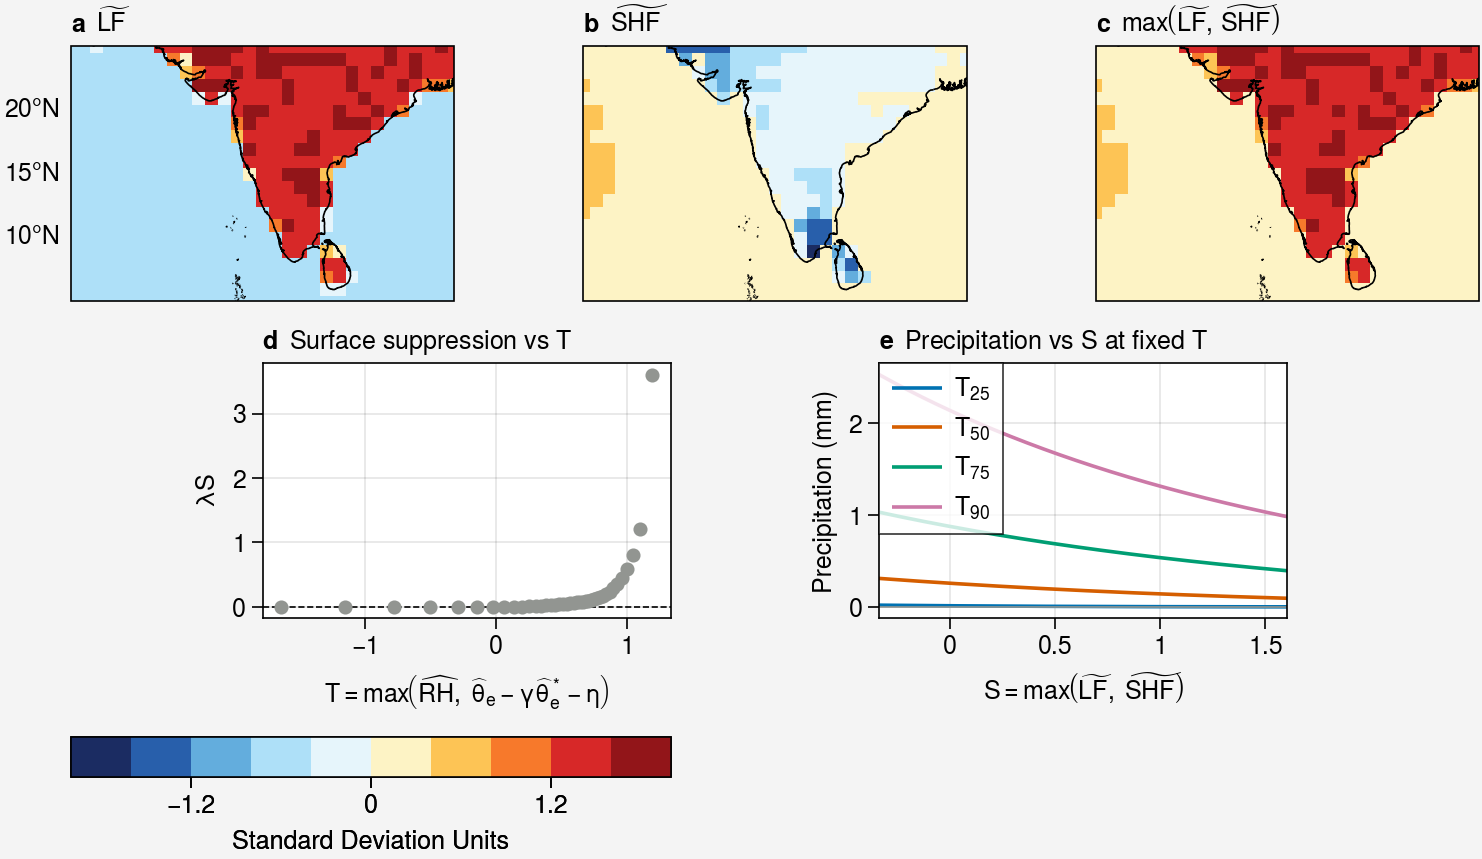

In [5]:
if 'sr_hi' not in SR_REGISTRY or shfnorm is None or lfnorm is None:
    print('sr_hi not in registry or surface vars missing — skipping')
else:
    c = SR_REGISTRY['sr_hi']['constants']
    ah,bh,ch,dh = c['a'],c['b'],c['c'],c['d']
    Mhi = rhk[valid]; Ihi = thetaek[valid]+bh*thetaestark[valid]+ch
    T   = np.maximum(Mhi,Ihi)
    S   = np.maximum(lfnorm[valid],shfnorm[valid])
    P   = trueflat[valid]
    Tlo,Thi = prange(T); Slo,Shi = prange(S)
    latlim = (float(lats.min()),float(lats.max()))
    lonlim = (float(lons.min()),float(lons.max()))
    lfmean2d  = lfnorm.reshape(refshape).mean(axis=0)
    shfmean2d = shfnorm.reshape(refshape).mean(axis=0)
    maxmean2d = np.maximum(lfnorm,shfnorm).reshape(refshape).mean(axis=0)
    climlim   = float(np.nanmax(np.abs([lfmean2d,shfmean2d,maxmean2d])))
    supp = to_phys((ah*T)**3)-to_phys((ah*T+dh*S)**3)
    _,Tcen,suppmeans,_ = bin1d(T,supp)
    Ssw    = np.linspace(Slo,Shi,200)
    Tpcts  = [25,50,75,90]
    Tfixed = np.percentile(T,Tpcts)
    labelT = r'$T = \max\!\left(\widehat{\mathrm{RH}},\;\widehat{\theta}_e - \gamma\widehat{\theta}_e^* - \eta\right)$'
    labelS = r'$S = \max\!\left(\widetilde{\mathrm{LF}},\;\widetilde{\mathrm{SHF}}\right)$'
    kwmap  = dict(coast=True,lonlim=lonlim,latlim=latlim,lonlines=5,latlines=[10,15,20],grid=False)
    kwsfc  = dict(cmap='ColdHot',vmin=-climlim,vmax=climlim)
    fig,axs = pplt.subplots([[1,1,2,2,3,3],[0,4,4,5,5,0]],figwidth=7.5,
                             proj={1:'cyl',2:'cyl',3:'cyl'},share=False,hspace=5)
    ms = axs[0].pcolormesh(lons,lats,lfmean2d,**kwsfc)
    axs[1].pcolormesh(lons,lats,shfmean2d,**kwsfc)
    axs[2].pcolormesh(lons,lats,maxmean2d,**kwsfc)
    axs[0].format(title=r'$\widetilde{\mathrm{LF}}$',latlabels='l',lonlabels='b',**kwmap)
    axs[1].format(title=r'$\widetilde{\mathrm{SHF}}$',lonlabels='b',**kwmap)
    axs[2].format(title=r'$\max\!\left(\widetilde{\mathrm{LF}},\,\widetilde{\mathrm{SHF}}\right)$',lonlabels='b',**kwmap)
    axs[3].scatter(Tcen,suppmeans,color='gray',s=20,zorder=4)
    axs[3].axhline(0,color='k',lw=0.6,ls='--')
    axs[3].format(xlabel=labelT,ylabel=r'$\lambda S$',title='Surface suppression vs $T$')
    for perc,tv in zip(Tpcts,Tfixed):
        Psw = to_phys((ah*tv+dh*Ssw)**3)
        axs[4].plot(Ssw,Psw,label=f'$T_{{\\mathrm{{{perc}}}}}$',lw=1.3)
    axs[4].axhline(0,color='gray',lw=0.6)
    axs[4].format(xlabel=labelS,ylabel='Precipitation (mm)',title=r'Precipitation vs $S$ at fixed $T$')
    axs[4].legend(loc='ul',ncols=1,fontsize=7)
    fig.format(abc=True,titleloc='l')
    fig.canvas.draw()

    left  = axs[0].get_position().x0
    right = axs[2].get_position().x1
    bottom_toprow = min(axs[0].get_position().y0,axs[1].get_position().y0,axs[2].get_position().y0)
    top_bottomrow = max(axs[3].get_position().y1,axs[4].get_position().y1)
    gap    = bottom_toprow - top_bottomrow
    cbar_h = 0.025
    cbar_y = top_bottomrow + 0.3*gap

    cax = fig.add_axes([left, cbar_y, right-left, cbar_h])
    cb  = fig.colorbar(ms,cax=cax,orientation='horizontal',label='Standard Deviation Units')
    cb.ax.tick_params(labelsize=9)

    pplt.show()
    fig.save('../figs/fig_5.jpg')